# Classification of Text Documents using Naive Bayes

In natural language processing and machine learning Naive Bayes is a popular method for classifying text documents. It can be used to classifies documents into pre defined types based on likelihood of a word occurring by using Bayes theorem.

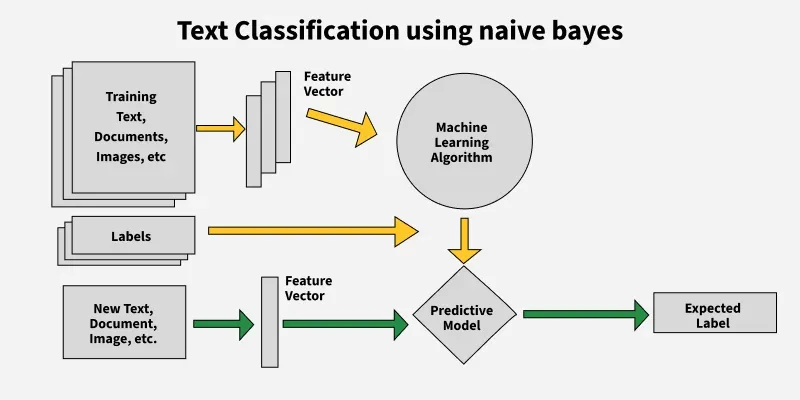!|

The dataset we will be using will be of text data categorized into four labels: Technology, Sports, Politics and Entertainment. Each entry contains a short sentence or statement related to a specific topic with the label indicating the category it belongs to.

# STEP 1: Import Libraries

We will need to import the necessary libraries like scikit-learn, Pandas, Matplotlib and Numpy.

- CountVectorizer to convert text data into numerical features using word counts.
- MultinomialNB: The Naive Bayes classifier for multinomial data and is ideal for text classification.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.feature_extraction.text import CountVectorizer

# STEP 2: Load The Dataset

In [5]:
data = pd.read_csv('synthetic_text_data.csv')
X = data['text']
y = data['label']

In [6]:
data.head()

,text,label
0,Artificial intelligence is advancing in health...,Technology
1,Football fans are excited about the upcoming W...,Sports
2,New policies regarding climate change have spa...,Politics
3,The latest blockbuster movie has shattered box...,Entertainment
4,Quantum computing promises to revolutionize in...,Technology


# STEP 3: Splitting the Data

Now we split the dataset into training and testing sets. 

- The training set is used to train the model while the testing set is used to evaluate its performance.

- train_test_split: Splits the data into training (80%) and testing (20%) sets. random_state: ensures reproducibility.

In [7]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# STEP 4: Text Preprocessing: Converting Text to Numeric Features

We need to convert the text data into numerical format before feeding it to the model. We use CountVectorizer to convert the text into a matrix of token counts.

- CountVectorizer(): Converts the raw text into a matrix of word counts.
- fit_transform(): Learns the vocabulary from the training data and transforms the text into vector.
- transform(): Applies the learned vocabulary from the training data to the test data.

In [8]:
vectorizer = CountVectorizer()
X_train_vectorized = vectorizer.fit_transform(X_train)
X_test_vectorized = vectorizer.transform(X_test)

# STEP 5: Training the Naive Bayes Classifier

With the data now in the right format we train the Naive Bayes classifier on the training data. Here we use Multinomial Naive Bayes.
Multinomial Naive Bayes is a variant of the Naive Bayes classifier specifically suited for classification tasks where the features or input data are discrete such as word counts or frequencies in text classification.

In [9]:
model = MultinomialNB()
model.fit(X_train_vectorized, y_train)

,alpha,1.0
,force_alpha,True
,fit_prior,True
,class_prior,None


# STEP 6: Making Predictions

In [10]:
# Now that the model is trained we can use it to predict the labels for the test data using X_test_vectorized.
y_pred = model.predict(X_test_vectorized)

# STEP 7: Evaluating the Model

After making predictions we need to evaluate the model's performance. We'll calculate the accuracy and confusion matrix to understand how well the model is performing.

- **accuracy_score():** Calculates the accuracy of the model by comparing the predicted labels (y_pred) with the true labels (y_test).
- **confusion_matrix():** Generates a confusion matrix to visualize how well the model classifies each category.

Accuracy: 88.23529411764706%


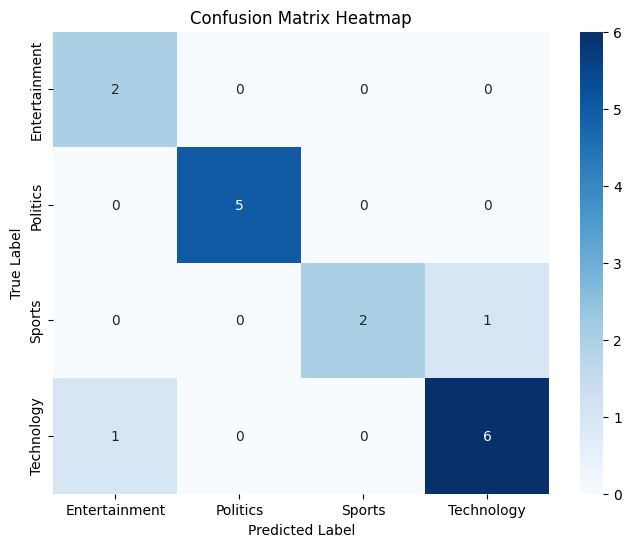

In [11]:
accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)

print(f'Accuracy: {accuracy *100}%')

class_labels = np.unique(y_test)

plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=class_labels, yticklabels=class_labels)
plt.title('Confusion Matrix Heatmap')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

Looking at the confusion matrix heatmap we can see the model made correct predictions for Sports (2), Technology (5), Politics (2) and Entertainment (6). Heatmap shows these values with darker colors representing correct predictions. However there were some misclassifications.

# STEP 8: Prediction on Unseen Data

In [12]:
user_input = ("I love artificial intelligence and machine learning")

user_input_vectorized = vectorizer.transform([user_input])
predicted_label = model.predict(user_input_vectorized)
print(f"The input text belongs to the '{predicted_label[0]}' category.")

The input text belongs to the 'Technology' category.
